## Initialization

In [1]:
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astroquery.jplhorizons import Horizons
from lamberthub import gooding1990
from astropy.time import Time
import matplotlib.dates as mdates

AU_KM = 149_597_870.7
DAY_S = 86_400.0

MU_SUN = 2.959122082855911e-4 # AU^3 / day^2


@dataclass(frozen=True)
class StateVector:
    r: np.ndarray  # position [AU], shape=(3,)
    v: np.ndarray  # velocity [AU/day], shape=(3,)


@dataclass(frozen=True)
class TransferResult:
    v_dep: np.ndarray  # heliocentric departure velocity [AU/day]
    v_arr: np.ndarray  # heliocentric arrival velocity [AU/day]
    vinf_dep: float    # Earth-relative departure v-infinity [km/s]
    vinf_arr: float    # AA29-relative arrival v-infinity [km/s]
    c3: float          # Earth departure C3 [km^2/s^2]
    tof_days: float    # flight time [day]

In [3]:
def au_per_day_to_km_per_s(value):
    return np.asarray(value) * AU_KM / DAY_S

def state_from_horizons(table, index):
    return StateVector(
        r=np.array(
            [table["x"][index], table["y"][index], table["z"][index]],
            dtype=float,
        ),
        v=np.array(
            [table["vx"][index], table["vy"][index], table["vz"][index]],
            dtype=float,
        ),
    )

def state_from_table(table, index):
    row = table.iloc[index]

    return StateVector(
        r=row[["x", "y", "z"]].to_numpy(dtype=float),
        v=row[["vx", "vy", "vz"]].to_numpy(dtype=float),
    )

def solve_lambert(
    earth_dep: StateVector,
    target_arr: StateVector,
    dep_jd: float,
    arr_jd: float,
    *,
    mu: float = MU_SUN,
) -> TransferResult:
    tof_days = float(arr_jd - dep_jd)

    v_sc_departure, v_sc_arrival = gooding1990(
        mu,
        earth_dep.r,
        target_arr.r,
        tof_days,
        M=0,
        prograde=True,
        low_path=True,
    )

    vinf_dep_au_day = np.linalg.norm(v_sc_departure - earth_dep.v)
    vinf_arr_au_day = np.linalg.norm(v_sc_arrival - target_arr.v)

    vinf_dep_km_s = float(au_per_day_to_km_per_s(vinf_dep_au_day))
    vinf_arr_km_s = float(au_per_day_to_km_per_s(vinf_arr_au_day))

    return TransferResult(
        v_dep=v_sc_departure,
        v_arr=v_sc_arrival,
        vinf_dep=vinf_dep_km_s,
        vinf_arr=vinf_arr_km_s,
        c3=vinf_dep_km_s**2,
        tof_days=tof_days,
    )

def get_pareto_front(df):
    df = df.sort_values("c3_km2_s2")

    best_vinf_arr = np.inf
    pareto_indices = []

    for index, row in df.iterrows():
        if row["vinf_arr_km_s"] < best_vinf_arr:
            pareto_indices.append(index)
            best_vinf_arr = row["vinf_arr_km_s"]

    return df.loc[pareto_indices]

def propagate_sun_2body(r0, v0, dt_days, mu=MU_SUN):
    y0 = np.hstack((r0, v0))

    def rhs(_, y):
        r = y[:3]
        v = y[3:]
        a = -mu * r / np.linalg.norm(r)**3
        return np.hstack((v, a))

    solution = solve_ivp(
        rhs,
        (0.0, dt_days),
        y0,
        rtol=1e-12,
        atol=1e-14,
    )

    return solution.y[:3, -1], solution.y[3:, -1]

def get_rotation_coords(vec_particle, vec_secondary):
    theta = np.arctan2(vec_secondary['y'], vec_secondary['x'])
    omega = (vec_secondary['x'] * vec_secondary['vy'] - vec_secondary['y'] * vec_secondary['vx']) \
            / (vec_secondary['x']**2 + vec_secondary['y']**2)

    dx = vec_particle['x'] - vec_secondary['x']
    dy = vec_particle['y'] - vec_secondary['y']
    dz = vec_particle['z'] - vec_secondary['z']
    
    dvx = vec_particle['vx'] - vec_secondary['vx']
    dvy = vec_particle['vy'] - vec_secondary['vy']
    dvz = vec_particle['vz'] - vec_secondary['vz']
    
    x_rot = dx * np.cos(theta) + dy * np.sin(theta)
    y_rot = -dx * np.sin(theta) + dy * np.cos(theta)
    z_rot = dz
    
    vx_rot = (dvx * np.cos(theta) + dvy * np.sin(theta)) + (omega * y_rot)
    vy_rot = (-dvx * np.sin(theta) + dvy * np.cos(theta)) - (omega * x_rot)
    vz_rot = dvz
    
    return pd.DataFrame({
        'x': x_rot, 'y': y_rot, 'z': z_rot,
        'vx': vx_rot, 'vy': vy_rot, 'vz': vz_rot
    })

## 2100s (Horizons Data)

In [4]:
epochs = {
    "start": "2090-01-01",
    "stop": "2110-01-01",
    "step": "1d",
}

earth_2100 = Horizons(
    id="399",             # Earth center
    location="@sun",
    epochs=epochs,
)
earth_2100_vec = earth_2100.vectors(refplane="ecliptic")

aa29_2100 = Horizons(
    id="2002 AA29",
    id_type="smallbody",
    location="@sun",
    epochs=epochs,
)
aa29_2100_vec = aa29_2100.vectors(refplane="ecliptic")

In [5]:
DEP_START_INDEX = 0
DEP_STOP_INDEX = 9 * 365

TOF_MIN_DAYS = 30
TOF_MAX_DAYS = 730

DATE_STEP_DAYS = 5
TOF_STEP_DAYS = 5

result_2100 = []

for dep_index in range(
    DEP_START_INDEX,
    DEP_STOP_INDEX + 1,
    DATE_STEP_DAYS,
):
    for tof_days in range(
        TOF_MIN_DAYS,
        TOF_MAX_DAYS + 1,
        TOF_STEP_DAYS,
    ):
        arr_index = dep_index + tof_days

        if arr_index >= len(aa29_2100_vec):
            continue

        try:
            result = solve_lambert(
                state_from_horizons(earth_2100_vec, dep_index),
                state_from_horizons(aa29_2100_vec, arr_index),
                earth_2100_vec["datetime_jd"][dep_index],
                aa29_2100_vec["datetime_jd"][arr_index],
            )
        except ValueError:
            continue

        result_2100.append({
            "dep_jd": earth_2100_vec["datetime_jd"][dep_index],
            "arr_jd": aa29_2100_vec["datetime_jd"][arr_index],
            "tof_days": result.tof_days,
            "c3_km2_s2": result.c3,
            "vinf_dep_km_s": result.vinf_dep,
            "vinf_arr_km_s": result.vinf_arr,
            "revolutions": 0,
        })

result_2100_df = pd.DataFrame(result_2100)
pareto_2100_df = get_pareto_front(result_2100_df)
low_c3_2100 = result_2100_df.query("c3_km2_s2 <= 50")

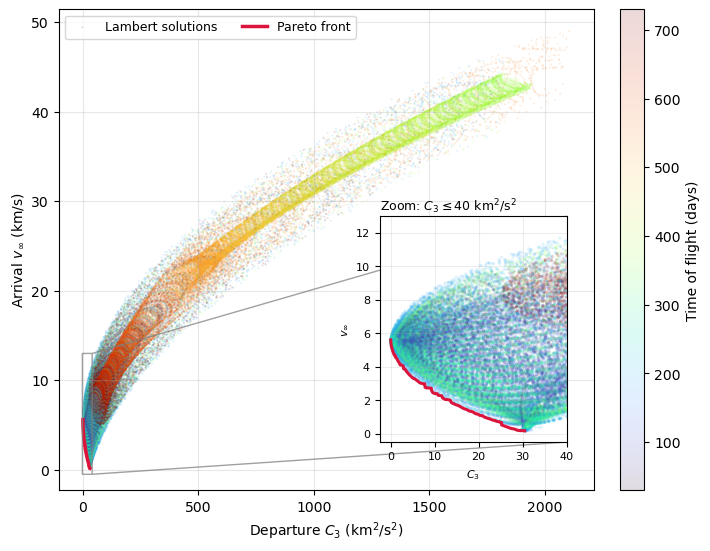

In [28]:
fig, ax1 = plt.subplots(figsize=(7, 5.4), constrained_layout=True)

# 전체 탐색 공간
sc = ax1.scatter(
    result_2100_df["c3_km2_s2"],
    result_2100_df["vinf_arr_km_s"],
    c=result_2100_df["tof_days"],
    cmap="turbo",
    s=2,
    alpha=0.15,
    edgecolors="none",
    rasterized=True,
    label="Lambert solutions",
    zorder=1,
)

ax1.plot(
    pareto_2100_df["c3_km2_s2"],
    pareto_2100_df["vinf_arr_km_s"],
    color="crimson",
    linewidth=2.5,
    label="Pareto front",
    zorder=3,
)

ax1.set_xlabel(r"Departure $C_3$ (km$^2$/s$^2$)")
ax1.set_ylabel(r"Arrival $v_\infty$ (km/s)")
ax1.legend(ncol=2, fontsize=9, loc="upper left")
ax1.grid(alpha=0.3)

# 확대창: [왼쪽, 아래, 너비, 높이] — 모두 ax1 내부 비율
ax2 = ax1.inset_axes([0.6, 0.10, 0.35, 0.47])
ax2.set_facecolor("white")

ax2.scatter(
    low_c3_2100["c3_km2_s2"],
    low_c3_2100["vinf_arr_km_s"],
    c=low_c3_2100["tof_days"],
    cmap="turbo",
    s=5,
    alpha=0.15,
    edgecolors="none",
    rasterized=True,
    zorder=1,
)

pareto_low = pareto_2100_df[
    pareto_2100_df["c3_km2_s2"] <= 40
]

ax2.plot(
    pareto_2100_df["c3_km2_s2"],
    pareto_2100_df["vinf_arr_km_s"],
    color="crimson",
    linewidth=2.2,
    zorder=3,
)

ax2.set_xlim(-2.5, 40)
ax2.set_ylim(-0.5, 13)
ax2.set_title(
    r"Zoom: $C_3 \leq 40$ km$^2$/s$^2$",
    loc="left",
    fontsize=9,
    pad=4,
)

ax2.set_xlabel(r"$C_3$", fontsize=8)
ax2.set_ylabel(r"$v_\infty$", fontsize=8)
ax2.tick_params(labelsize=8)
ax2.grid(alpha=0.22)

# 확대 대상 영역 사각형과 연결선
ax1.indicate_inset_zoom(
    ax2,
    edgecolor="gray",
    alpha=0.75,
    linewidth=1,
)

fig.colorbar(sc, ax=ax1, label="Time of flight (days)")

fig.savefig(
    "v_c3_2100.webp",
    format="webp",
    dpi=220,
    bbox_inches="tight",
)

plt.show()

### Sort Candidates

In [10]:
for c3_target in [10, 15, 20]:
    candidate= pareto_2100_df.loc[
        (pareto_2100_df["c3_km2_s2"] - c3_target).abs().idxmin()
    ]

    print(
        f"\nC3 ≈ {c3_target}"
        f"\nDeparture JD : {candidate['dep_jd']}"
        f"\nArrival JD   : {candidate['arr_jd']}"
        f"\nTOF          : {candidate['tof_days']:.0f} days"
        f"\nC3           : {candidate['c3_km2_s2']:.3f} km²/s²"
        f"\nArrival v∞   : {candidate['vinf_arr_km_s']:.3f} km/s"
    )


C3 ≈ 10
Departure JD : 2487157.5
Arrival JD   : 2487357.5
TOF          : 200 days
C3           : 10.096 km²/s²
Arrival v∞   : 2.392 km/s

C3 ≈ 15
Departure JD : 2487157.5
Arrival JD   : 2487362.5
TOF          : 205 days
C3           : 15.085 km²/s²
Arrival v∞   : 1.701 km/s

C3 ≈ 20
Departure JD : 2487522.5
Arrival JD   : 2487737.5
TOF          : 215 days
C3           : 19.788 km²/s²
Arrival v∞   : 1.171 km/s


### Lambert for C3<20 (precise)

In [15]:
dep_selected_2100 = 2487522.5
arr_selected_2100 = 2487737.5

refined_results_2100 = []

for dep_jd in np.arange(dep_selected_2100 - 20, dep_selected_2100 + 21, 1):
    for arr_jd in np.arange(arr_selected_2100 - 20, arr_selected_2100 + 21, 1):
        if arr_jd <= dep_jd:
            continue

        dep_index = np.argmin(
            np.abs(earth_2100_vec["datetime_jd"] - dep_jd)
        )
        arr_index = np.argmin(
            np.abs(aa29_2100_vec["datetime_jd"] - arr_jd)
        )

        result = solve_lambert(
            state_from_horizons(earth_2100_vec, dep_index),
            state_from_horizons(aa29_2100_vec, arr_index),
            earth_2100_vec["datetime_jd"][dep_index],
            aa29_2100_vec["datetime_jd"][arr_index],
        )

        refined_results_2100.append({
            "dep_jd": earth_2100_vec["datetime_jd"][dep_index],
            "arr_jd": aa29_2100_vec["datetime_jd"][arr_index],
            "tof_days": result.tof_days,
            "c3_km2_s2": result.c3,
            "vinf_arr_km_s": result.vinf_arr,
        })

refined_2100_df = pd.DataFrame(refined_results_2100)

reference_2100 = (
    refined_2100_df
    .query("c3_km2_s2 <= 20")
    .nsmallest(1, "vinf_arr_km_s")
)

candidate_2100 = reference_2100.iloc[0]

dep_jd = candidate_2100["dep_jd"]
arr_jd = candidate_2100["arr_jd"]

dep_index = np.argmin(
    np.abs(earth_2100_vec["datetime_jd"] - dep_jd)
)
arr_index = np.argmin(
    np.abs(aa29_2100_vec["datetime_jd"] - arr_jd)
)

earth_dep = state_from_horizons(earth_2100_vec, dep_index)
aa29_arr = state_from_horizons(aa29_2100_vec, arr_index)

result = solve_lambert(
    earth_dep,
    aa29_arr,
    dep_jd,
    arr_jd,
)

r_dep = earth_dep.r
v_earth_dep = earth_dep.v

v_sc_dep = result.v_dep
v_sc_arr = result.v_arr


r_sc_15d, v_sc_15d = propagate_sun_2body(
    r0=r_dep,
    v0=v_sc_dep,
    dt_days=15.0,
)

print(f"Departure JD : {dep_jd:.1f}")
print(f"Arrival JD   : {arr_jd:.1f}")
print(f"TOF          : {result.tof_days:.1f} days")
print(f"C3           : {result.c3:.6f} km²/s²")
print(f"Arrival v∞   : {result.vinf_arr:.6f} km/s")
print("r [AU]   :", r_dep)
print("v [AU/day] :", v_sc_dep)

print("\n=== after 15 days ===")
print("JD                  :", dep_jd + 15.0)
print("r [AU]              :", r_sc_15d)
print("v [AU/day]          :", v_sc_15d)

Departure JD : 2487526.5
Arrival JD   : 2487722.5
TOF          : 196.0 days
C3           : 19.949760 km²/s²
Arrival v∞   : 1.065905 km/s
r [AU]   : [ 2.48187222e-01 -9.85870405e-01  2.14456145e-04]
v [AU/day] : [ 0.01638138  0.00388095 -0.00256713]

=== after 15 days ===
JD                  : 2487541.5
r [AU]              : [ 0.4835385  -0.89729962 -0.03789595]
v [AU/day]          : [ 0.0148363   0.0078598  -0.00248766]


### Error correction

In [31]:
ARR_JD = 2487722.5
DV_TEST = 1e-6  # AU/day



for axis, i in zip(["vx", "vy", "vz"], range(3)):
    v_test = v_sc_15d.copy()
    v_test[i] += DV_TEST

    print(f"\n=== {axis} + {DV_TEST:.1e} AU/day ===")
    print("r [AU]    :", r_sc_15d)
    print("v [AU/day]:", v_test)


=== vx + 1.0e-06 AU/day ===
r [AU]    : [ 0.4835385  -0.89729962 -0.03789595]
v [AU/day]: [ 0.0148373   0.0078598  -0.00248766]

=== vy + 1.0e-06 AU/day ===
r [AU]    : [ 0.4835385  -0.89729962 -0.03789595]
v [AU/day]: [ 0.0148363   0.0078608  -0.00248766]

=== vz + 1.0e-06 AU/day ===
r [AU]    : [ 0.4835385  -0.89729962 -0.03789595]
v [AU/day]: [ 0.0148363   0.0078598  -0.00248666]


In [39]:
ARR_JD = 2487722.5
DV_TEST = 1e-6  # AU/day

col = ['time', 'x', 'y', 'z', 'vx', 'vy', 'vz']

earth_run1_vec = pd.read_csv('EARTH_run1.aei', sep=r'\s+', skiprows=4, names=col)
aa29_run1_vec = pd.read_csv('2002AA29_run1.aei', sep=r'\s+', skiprows=4, names=col)
space_run1_vec = pd.read_csv('SPACECRAFT_run1.aei', sep=r'\s+', skiprows=4, names=col)

x_earth_run1, y_earth_run1, z_earth_run1 = earth_run1_vec['x'], earth_run1_vec['y'], earth_run1_vec['z']
x_aa29_run1, y_aa29_run1, z_aa29_run1 = aa29_run1_vec['x'], aa29_run1_vec['y'], aa29_run1_vec['z']

space_vec_vx = pd.read_csv('SPACECRAFT-vx.aei', sep=r'\s+', skiprows=4, names=col)
space_vec_vy = pd.read_csv('SPACECRAFT-vy.aei', sep=r'\s+', skiprows=4, names=col)
space_vec_vz = pd.read_csv('SPACECRAFT-vz.aei', sep=r'\s+', skiprows=4, names=col)

initial_velocity = np.array([
    0.0148363,
    0.0078598,
   -0.00248766,
])

def au_per_day_to_m_per_s(value):
    return np.asarray(value) * AU_KM * 1000 / DAY_S

def miss_vector(vec_sc, vec_aa29, arr_jd=ARR_JD):
    df = (
        vec_sc.merge(vec_aa29, on="time", suffixes=("_sc", "_aa29"))
        .sort_values("time")
    )

    row = df.loc[(df["time"] - arr_jd).abs().idxmin()]

    return np.array([
        row["x_sc"] - row["x_aa29"],
        row["y_sc"] - row["y_aa29"],
        row["z_sc"] - row["z_aa29"],
    ])

dr0 = miss_vector(space_run1_vec, aa29_run1_vec)
dr0_total = np.linalg.norm(dr0)
drx = miss_vector(space_vec_vx, aa29_run1_vec)
dry = miss_vector(space_vec_vy, aa29_run1_vec)
drz = miss_vector(space_vec_vz, aa29_run1_vec)

J0 = np.column_stack([
    (drx - dr0) / DV_TEST,
    (dry - dr0) / DV_TEST,
    (drz - dr0) / DV_TEST,
])

dv1 = np.linalg.solve(J0, -dr0)
velocity_run2 = initial_velocity + dv1

print("Run 1 miss [km]:", dr0 * AU_KM)
print("Run 1 miss norm [km]:", dr0_total * AU_KM)
print("First correction [m/s]:", au_per_day_to_m_per_s(dv1))
print("Run 2 initial velocity [AU/day]:", velocity_run2)

Run 1 miss [km]: [-80023.67090377 -51595.36313785  67487.93781102]
Run 1 miss norm [km]: 116706.85991930836
First correction [m/s]: [ -8.61649435  -5.10867713 -73.27546606]
Run 2 initial velocity [AU/day]: [ 0.01483132  0.00785685 -0.00252998]


In [35]:
space_run2_vec = pd.read_csv("SPACECRAFT-run2.aei", sep=r"\s+", skiprows=4, names=col,)

dr1 = miss_vector(space_run2_vec, aa29_run1_vec)
dr1_total = np.linalg.norm(dr1)

dv2 = np.linalg.solve(J0, -dr1)
velocity_run3 = velocity_run2 + dv2

print("Run 2 miss [km]:", dr1 * AU_KM)
print("Run 2 miss norm [km]:", dr1_total * AU_KM)
print("Second correction [m/s]:", au_per_day_to_m_per_s(dv2))
print("Run 3 initial velocity [AU/day]:", velocity_run3)


Run 2 miss [km]: [2901.39086308 2969.09885935 -822.44421375]
Run 2 miss norm [km]: 4232.024510993254
Second correction [m/s]: [-0.01901654 -0.0203404   0.39587102]
Run 3 initial velocity [AU/day]: [ 0.01483131  0.00785684 -0.00252975]


In [40]:
space_run3_vec = pd.read_csv("SPACECRAFT-run3.aei", sep=r"\s+", skiprows=4, names=col,)
x_space_run3, y_space_run3, z_space_run3 = space_run3_vec['x'], space_run3_vec['y'], space_run3_vec['z']

dr2 = miss_vector(space_run3_vec, aa29_run1_vec)
dr2_total = np.linalg.norm(dr2)

dv3 = np.linalg.solve(J0, -dr2)
velocity_run4 = velocity_run3 + dv3

print("Run 3 miss [km]:", dr2 * AU_KM)
print("Run 3 miss norm [km]:", dr2_total * AU_KM)

print(
    "Net correction [m/s]:",
    np.linalg.norm(au_per_day_to_m_per_s(velocity_run4 - initial_velocity)),
)

Run 3 miss [km]: [17.66750853 41.27405252  9.21522884]
Run 3 miss norm [km]: 45.83239805578092
Net correction [m/s]: 73.58686289502639


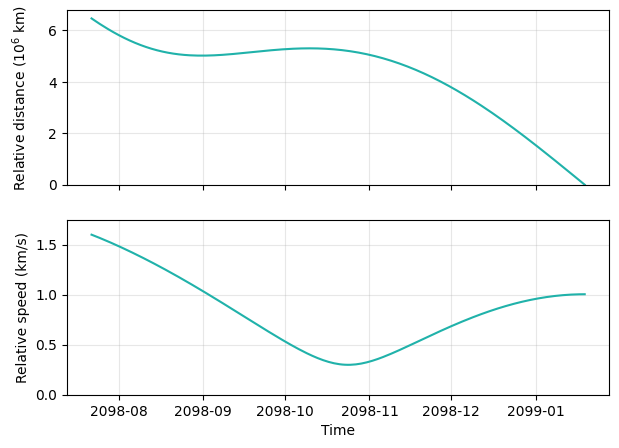

Final distance : 45.8 km
Minimum distance: 45.8 km
Final Δv       : 1.0048 km/s


In [130]:
df = (
    space_run3_vec.merge(aa29_run1_vec, on="time", suffixes=("_sc", "_aa29"))
    .sort_values("time")
)

time_date = Time(
    df["time"].to_numpy(),
    format="jd",
    scale="tdb",
).to_datetime()

dr_au = np.sqrt(
    (df["x_sc"] - df["x_aa29"])**2
    + (df["y_sc"] - df["y_aa29"])**2
    + (df["z_sc"] - df["z_aa29"])**2
)

dr_km = dr_au * AU_KM
dr_million_km = dr_km / 1e6

dv_km_s = np.sqrt(
    (df["vx_sc"] - df["vx_aa29"])**2
    + (df["vy_sc"] - df["vy_aa29"])**2
    + (df["vz_sc"] - df["vz_aa29"])**2
) * AU_KM / DAY_S

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(7, 5),
    sharex=True,
)

ax1.plot(time_date, dr_million_km, color="lightseagreen")
ax1.set_ylabel(r"Relative distance ($10^6$ km)")
ax1.set_ylim(0, 6.8)
ax1.grid(alpha=0.3)

ax2.plot(time_date, dv_km_s, color="lightseagreen")
ax2.set_xlabel("Time")
ax2.set_ylabel(r"Relative speed (km/s)")
ax2.set_ylim(0, 1.75)
ax2.grid(alpha=0.3)

fig.align_ylabels()

fig.savefig(
    "aa29_approach_parameters.webp",
    format="webp",
    dpi=220,
    bbox_inches="tight",
)

plt.show()

print(f"Final distance : {dr_km.iloc[-1]:,.1f} km")
print(f"Minimum distance: {dr_km.min():,.1f} km")
print(f"Final Δv       : {dv_km_s.iloc[-1]:.4f} km/s")

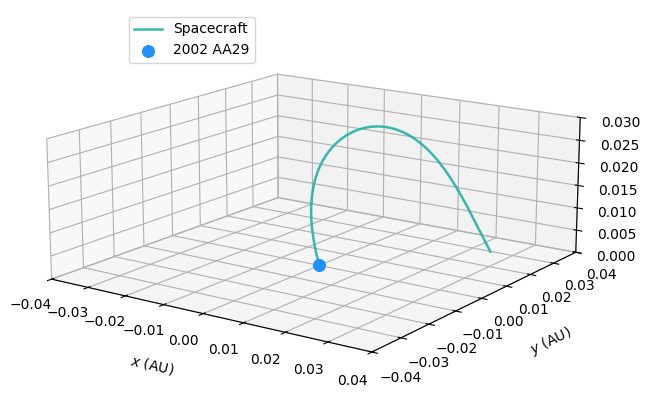

In [133]:
vec_space_rot = get_rotation_coords(space_run3_vec, aa29_run1_vec)
x_rot, y_rot, z_rot = vec_space_rot['x'], vec_space_rot['y'], vec_space_rot['z']

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection="3d")

ax.plot(
    x_rot, y_rot, z_rot,
    color="lightseagreen",
    lw=1.8,
    alpha=0.9,
    label="Spacecraft",
)

ax.scatter(
    0, 0, 0,
    color="dodgerblue",
    s=70,
    depthshade=False,
    label="2002 AA29",
    zorder=5,
)

ax.set_xlim(-0.04, 0.04)
ax.set_ylim(-0.04, 0.04)
ax.set_zlim(0, 0.03)

ax.set_xlabel("$x$ (AU)", labelpad=8)
ax.set_ylabel("$y$ (AU)", labelpad=8)
ax.set_zlabel("$z$ (AU)", labelpad=8)

ax.view_init(elev=15, azim=-55)
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
ax.set_box_aspect((1, 1, 0.375), zoom=1.4)

fig.savefig(
    "aa29_approach_3d.webp",
    format="webp",
    dpi=220,
    bbox_inches="tight",
)

plt.show()

## 2600s (mercury6)

In [124]:
col = ['time', 'x', 'y', 'z', 'vx', 'vy', 'vz', 'a', 'e', 'i', 'g', 'n', 'M']

earth_2600_vec = pd.read_csv('EARTH.aei', sep=r'\s+', skiprows=4, names=col)
aa29_2600_vec = pd.read_csv('2002AA29.aei', sep=r'\s+', skiprows=4, names=col)

In [125]:
DEP_START_INDEX = 27 * 365
DEP_STOP_INDEX = 37 * 365

TOF_MIN_DAYS = 30
TOF_MAX_DAYS = 730

DATE_STEP_DAYS = 5
TOF_STEP_DAYS = 5

results_2600 = []

for dep_index in range(
    DEP_START_INDEX,
    DEP_STOP_INDEX + 1,
    DATE_STEP_DAYS,
):
    for tof_days in range(
        TOF_MIN_DAYS,
        TOF_MAX_DAYS + 1,
        TOF_STEP_DAYS,
    ):
        arr_index = dep_index + tof_days

        if arr_index >= len(aa29_2600_vec):
            continue

        try:
            result = solve_lambert(
                state_from_table(earth_2600_vec, dep_index),
                state_from_table(aa29_2600_vec, arr_index),
                earth_2600_vec["time"][dep_index],
                aa29_2600_vec["time"][arr_index],
            )
        except ValueError:
            continue

        results_2600.append({
            "dep_jd": earth_2600_vec["time"][dep_index],
            "arr_jd": aa29_2600_vec["time"][arr_index],
            "tof_days": result.tof_days,
            "c3_km2_s2": result.c3,
            "vinf_dep_km_s": result.vinf_dep,
            "vinf_arr_km_s": result.vinf_arr,
            "revolutions": 0,
        })

results_2600_df = pd.DataFrame(results_2600)
pareto_2600_df = get_pareto_front(results_2600_df)
low_c3_2600 = results_2600_df.query("c3_km2_s2 <= 50")

KeyboardInterrupt: 

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 8), constrained_layout=True)

ax1.scatter(
    results_2600_df["c3_km2_s2"],
    results_2600_df["vinf_arr_km_s"],
    s=2,
    color="lightseagreen",
    alpha=0.15,
    label="Lambert solutions",
)

ax1.plot(
    pareto_2600_df["c3_km2_s2"],
    pareto_2600_df["vinf_arr_km_s"],
    color="darkslategray",
    linewidth=2,
    label="Pareto front",
)

ax1.set_ylabel(r"Arrival $v_\infty$ (km/s)")
ax1.legend(ncol=2, fontsize=9)
ax1.grid(alpha=0.3)

ax2.scatter(
    low_c3_2600["c3_km2_s2"],
    low_c3_2600["vinf_arr_km_s"],
    s=5,
    color="lightseagreen",
    alpha=0.15,
    label=r"Lambert solutions ($C_3 \leq 50$ km$^2$/s$^2$)",
)

ax2.plot(
    pareto_2600_df["c3_km2_s2"],
    pareto_2600_df["vinf_arr_km_s"],
    color="darkslategray",
    linewidth=2,
    label="Pareto front",
)

ax2.set_xlabel(r"$C_3$ (km$^2$/s$^2$)")
ax2.set_ylabel(r"Arrival $v_\infty$ (km/s)")
ax2.legend(ncol=2, fontsize=9)
ax2.grid(alpha=0.3)

fig.savefig(
    "v_c3_2600.webp",
    format="webp",
    dpi=220,
    bbox_inches="tight",
    pad_inches=0.06,
)

plt.show()

In [ ]:
plt.rcdefaults()
fig, (ax0, ax1) = plt.subplots(
    2, 1,
    figsize=(7, 6),
    sharex=True,
    height_ratios=[2.2, 1],
    constrained_layout=True,
)

# 위: 두 Pareto front와 그 차이
ax0.plot(c_grid, v_2100, color="dodgerblue", lw=2, label="2100s")
ax0.plot(c_grid, v_qs, color="lightseagreen", lw=2, label="Quasi-satellite phase")

ax0.fill_between(
    c_grid,
    v_2100,
    v_qs,
    color="gray",
    alpha=0.25,
    label=r"$\Delta v_\infty$",
)

ax0.set_ylabel(r"Arrival $v_\infty$ (km/s)")
ax0.set_xlim(c_grid.min(), c_grid.max())
ax0.legend()
ax0.grid(alpha=0.3)

# 아래: signed difference
ax1.axhline(0, color="black", lw=0.8)

ax1.fill_between(
    c_grid, 0, delta_vinf,
    where=delta_vinf >= 0,
    color="tab:red",
    alpha=0.35,
    label="QS worse",
)

ax1.fill_between(
    c_grid, 0, delta_vinf,
    where=delta_vinf < 0,
    color="tab:green",
    alpha=0.35,
    label="QS better",
)

ax1.plot(c_grid, delta_vinf, color="black", lw=1)

ax1.set_xlabel(r"$C_3$ (km$^2$/s$^2$)")
ax1.set_ylabel(r"$\Delta v_\infty$" "\n(km/s)")
ax1.legend(ncol=2, fontsize=9)
ax1.grid(alpha=0.3)

fig.savefig(
    "pareto_front_comparison.webp",
    format="webp",
    dpi=220,
    bbox_inches="tight",
    pad_inches=0.06,
)

plt.show()